In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

df_da = df[df['job_title_short'] == 'Data Analyst'].copy()

In [2]:
df_da['job_posted_month_no'] = df['job_posted_date'].dt.month

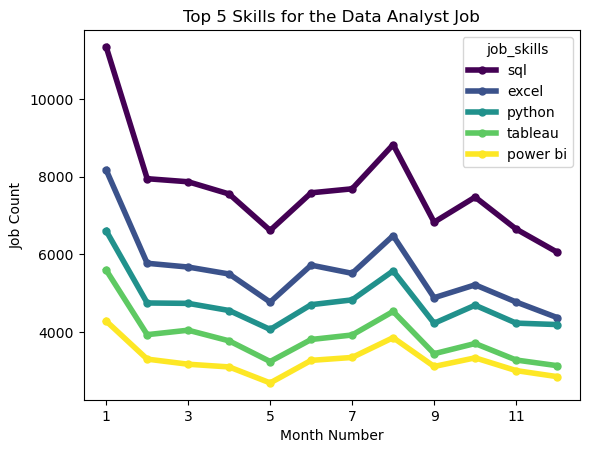

In [3]:
df_da_explode = df_da.explode('job_skills')
df_da_pivot = df_da_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
df_da_pivot.loc['Total'] = df_da_pivot.sum()
df_da_pivot = df_da_pivot[df_da_pivot.loc['Total'].sort_values(ascending=False).index]
df_da_pivot = df_da_pivot.drop('Total')

df_da_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth=4,
    linestyle='-',
    colormap='viridis',
    marker='o',
    markersize=5
)
plt.title('Top 5 Skills for the Data Analyst Job')
plt.xlabel('Month Number')
plt.ylabel('Job Count')
plt.show()

In [4]:
df_da_exploded1 = df_da.explode('job_skills')

In [5]:
skill_stats = df_da_exploded1.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    median_salary = ('salary_year_avg', 'median')
)

top_skills = 20
skills_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(top_skills)
skills_stats

,skill_count,median_salary
job_skills,,
sql,92428,92500.000000
excel,66860,84479.000000
python,57190,98500.000000
tableau,46455,95000.000000
power bi,39380,90000.000000
r,29996,92527.500000
sas,27998,90000.000000
powerpoint,13822,85000.000000
word,13562,80000.000000


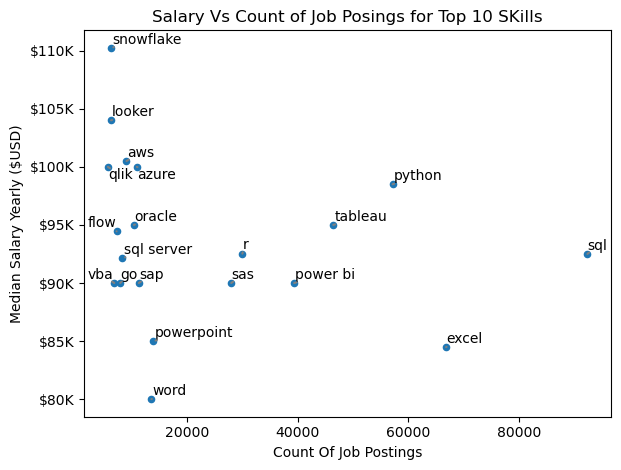

In [20]:
from adjustText import adjust_text
# fig, ax = plt.subplots()

skills_stats.plot(kind='scatter', x='skill_count', y='median_salary')
plt.title('Salary Vs Count of Job Posings for Top 10 SKills')
plt.xlabel('Count Of Job Postings')
plt.ylabel('Median Salary Yearly ($USD)')
plt.tight_layout()
texts=[]
for i, txt in enumerate(skills_stats.index):
    texts.append(plt.text(skills_stats['skill_count'].iloc[i], skills_stats['median_salary'].iloc[i], txt))
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=1.5))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()